In [ ]:
# ============================================
#    LOAD DATASET
# ============================================

df = pd.read_csv(
    "open-meteo-30.05N31.19E22m.csv",
    skiprows=2
)

print("Dataset Loaded Successfully!")
print()

print(df.head())

Dataset Loaded Successfully!

               time  temperature_2m (°C)  relative_humidity_2m (%)  \
0  2025-01-01T00:00                 10.4                        87   
1  2025-01-01T01:00                 10.5                        85   
2  2025-01-01T02:00                 10.1                        87   
3  2025-01-01T03:00                  9.6                        89   
4  2025-01-01T04:00                  9.5                        90   

   shortwave_radiation_instant (W/m²)  surface_pressure (hPa)  \
0                                 0.0                  1025.3   
1                                 0.0                  1025.3   
2                                 0.0                  1025.0   
3                                 0.0                  1025.1   
4                                 0.0                  1025.9   

   wind_speed_10m (km/h)  
0                    3.4  
1                    2.2  
2                    2.2  
3                    1.6  
4                    1.

In [ ]:
# ============================================
# DATA PREPROCESSING
# ============================================

# Rename columns for easier handling
df.columns = [
    "time",
    "temperature",
    "humidity",
    "solar_radiation",
    "surface_pressure",
    "wind_speed"
]

# Convert time column to datetime
df["time"] = pd.to_datetime(df["time"])

# Create time-based features
df["hour"] = df["time"].dt.hour
df["day"] = df["time"].dt.day
df["month"] = df["time"].dt.month

# Check dataset info
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

                 time  temperature  humidity  solar_radiation  \
0 2025-01-01 00:00:00         10.4        87              0.0   
1 2025-01-01 01:00:00         10.5        85              0.0   
2 2025-01-01 02:00:00         10.1        87              0.0   
3 2025-01-01 03:00:00          9.6        89              0.0   
4 2025-01-01 04:00:00          9.5        90              0.0   

   surface_pressure  wind_speed  hour  day  month  
0            1025.3         3.4     0    1      1  
1            1025.3         2.2     1    1      1  
2            1025.0         2.2     2    1      1  
3            1025.1         1.6     3    1      1  
4            1025.9         1.7     4    1      1  

Dataset Shape:
(4344, 9)

Missing Values:
time                0
temperature         0
humidity            0
solar_radiation     0
surface_pressure    0
wind_speed          0
hour                0
day                 0
month               0
dtype: int64


In [ ]:
# ============================================
# CREATE LAG FEATURES
# ============================================

# Temperature lag features
df["temp_lag_1"] = df["temperature"].shift(1)
df["temp_lag_2"] = df["temperature"].shift(2)
df["temp_lag_3"] = df["temperature"].shift(3)

# Humidity lag features
df["humidity_lag_1"] = df["humidity"].shift(1)
df["humidity_lag_2"] = df["humidity"].shift(2)
df["humidity_lag_3"] = df["humidity"].shift(3)

# ============================================
# CREATE FUTURE TARGETS
# ============================================

# Future temperature targets
df["temp_target_1h"] = df["temperature"].shift(-1)
df["temp_target_2h"] = df["temperature"].shift(-2)
df["temp_target_3h"] = df["temperature"].shift(-3)

# Future humidity targets
df["humidity_target_1h"] = df["humidity"].shift(-1)
df["humidity_target_2h"] = df["humidity"].shift(-2)
df["humidity_target_3h"] = df["humidity"].shift(-3)

# ============================================
# REMOVE EMPTY ROWS
# ============================================

df.dropna(inplace=True)

# ============================================
# DISPLAY RESULTS
# ============================================

print(df.head())

print("\nDataset Shape After Lagging:")
print(df.shape)

                 time  temperature  humidity  solar_radiation  \
3 2025-01-01 03:00:00          9.6        89              0.0   
4 2025-01-01 04:00:00          9.5        90              0.0   
5 2025-01-01 05:00:00          9.8        91              0.0   
6 2025-01-01 06:00:00         10.8        85            106.6   
7 2025-01-01 07:00:00         12.9        73            285.0   

   surface_pressure  wind_speed  hour  day  month  temp_lag_1  ...  \
3            1025.1         1.6     3    1      1        10.1  ...   
4            1025.9         1.7     4    1      1         9.6  ...   
5            1026.3         2.6     5    1      1         9.5  ...   
6            1026.8         3.5     6    1      1         9.8  ...   
7            1026.9         2.9     7    1      1        10.8  ...   

   temp_lag_3  humidity_lag_1  humidity_lag_2  humidity_lag_3  temp_target_1h  \
3        10.4            87.0            85.0            87.0             9.5   
4        10.5            8

In [ ]:
# ============================================
# SELECT FEATURES AND TARGET
# ============================================

# Input features
features = [
    "humidity",
    "solar_radiation",
    "surface_pressure",
    "wind_speed",
    "hour",
    "day",
    "month",
    "temp_lag_1",
    "temp_lag_2",
    "temp_lag_3",
    "humidity_lag_1",
    "humidity_lag_2",
    "humidity_lag_3"
]

# Target variable
target = "temp_target_1h"

# Feature matrix
X = df[features]

# Target vector
y = df[target]

# ============================================
# TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    shuffle=False
)

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape: (3904, 13)
Testing Shape : (434, 13)


In [ ]:
# ============================================
# TRAIN XGBOOST MODEL
# ============================================

model = XGBRegressor(
    n_estimators=10000,
    learning_rate=0.05,
    max_depth=5,
    subsample=1,
    colsample_bytree=1,
    objective='reg:squarederror',
    random_state=42
)

# Train model
model.fit(X_train, y_train)

print("XGBoost Model Trained Successfully!")

XGBoost Model Trained Successfully!


In [ ]:
# ============================================
# MAKE PREDICTIONS
# ============================================

y_pred = model.predict(X_test)

# ============================================
# EVALUATION METRICS
# ============================================

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# ============================================
# DISPLAY RESULTS
# ============================================

print("Model Performance:")
print()

print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

Model Performance:

RMSE: 0.8793
R² Score: 0.9757


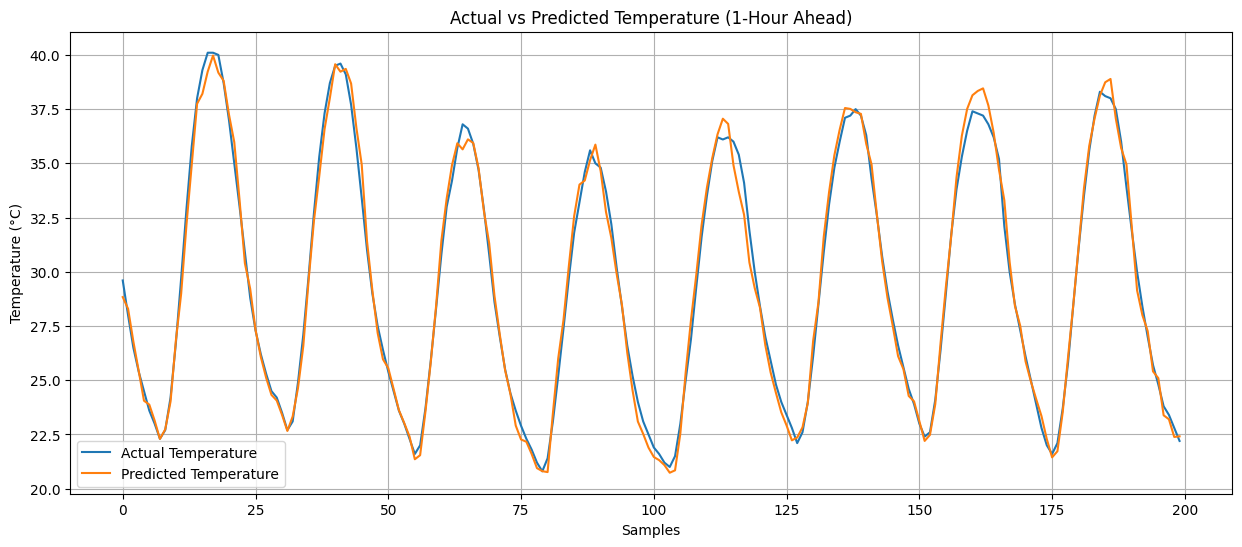

In [ ]:
# ============================================
# ACTUAL VS PREDICTED PLOT
# ============================================

plt.figure(figsize=(15,6))

plt.plot(y_test.values[:200], label="Actual Temperature")
plt.plot(y_pred[:200], label="Predicted Temperature")

plt.title("Actual vs Predicted Temperature (1-Hour Ahead)")
plt.xlabel("Samples")
plt.ylabel("Temperature (°C)")

plt.legend()
plt.grid(True)

plt.show()

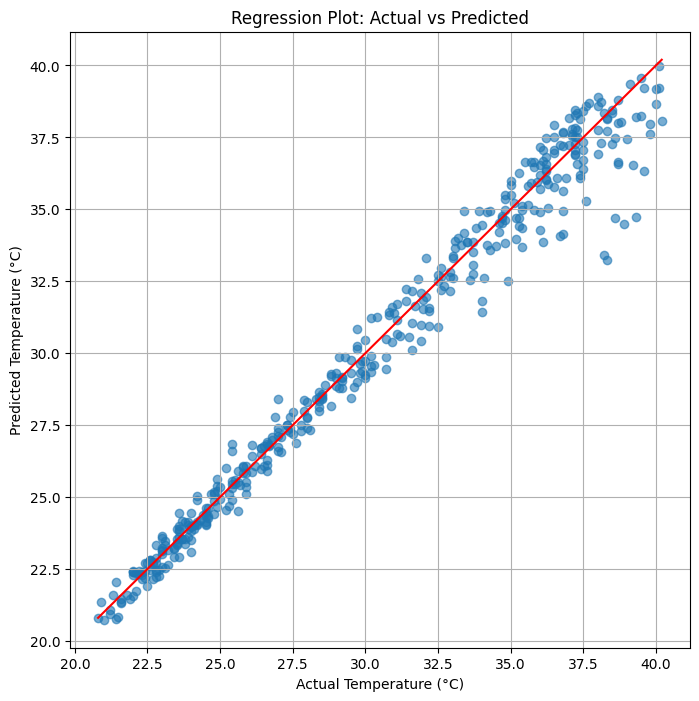

In [ ]:
# ============================================
# REGRESSION SCATTER PLOT
# ============================================

plt.figure(figsize=(8,8))

plt.scatter(y_test, y_pred, alpha=0.6)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r'
)

plt.xlabel("Actual Temperature (°C)")
plt.ylabel("Predicted Temperature (°C)")

plt.title("Regression Plot: Actual vs Predicted")

plt.grid(True)

plt.show()

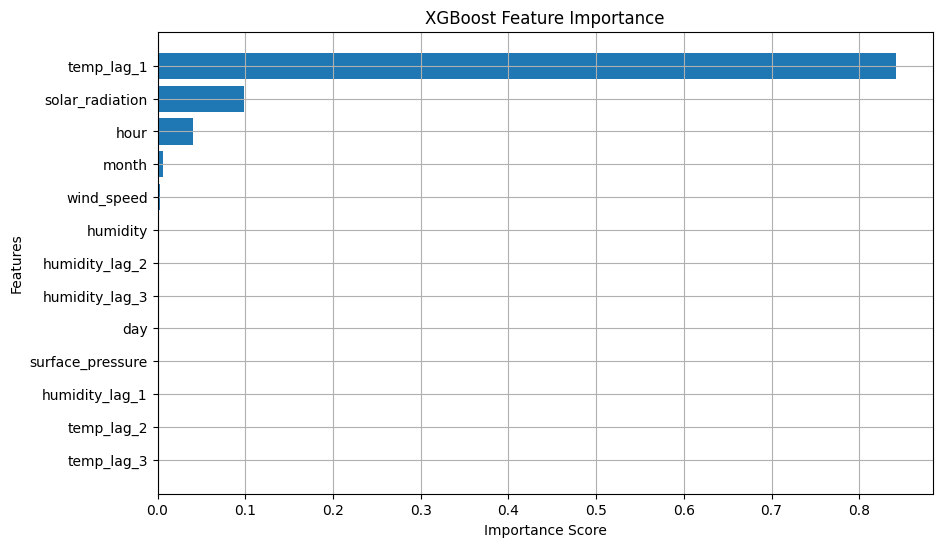

             Feature  Importance
7         temp_lag_1    0.841448
1    solar_radiation    0.098936
4               hour    0.039876
6              month    0.006593
3         wind_speed    0.002426
0           humidity    0.001800
11    humidity_lag_2    0.001585
12    humidity_lag_3    0.001564
5                day    0.001338
2   surface_pressure    0.001295
10    humidity_lag_1    0.001284
8         temp_lag_2    0.001024
9         temp_lag_3    0.000831


In [ ]:
# ============================================
# FEATURE IMPORTANCE PLOT
# ============================================

importance = model.feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

# Sort values
feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

# ============================================
# PLOT FEATURE IMPORTANCE
# ============================================

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance_df['Feature'],
    feature_importance_df['Importance']
)

plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()

plt.grid(True)

plt.show()

# Display values
print(feature_importance_df)

In [ ]:
# ============================================
# MULTI-HORIZON FORECASTING PIPELINE
# ============================================

# List of targets
targets = [
    "temp_target_1h",
    "temp_target_2h",
    "temp_target_3h",
    "humidity_target_1h",
    "humidity_target_2h",
    "humidity_target_3h"
]

# Store results
results = []

# ============================================
# TRAIN MODELS FOR EACH TARGET
# ============================================

for target in targets:

    print(f"\nTraining model for: {target}")

    # Features
    X = df[features]

    # Target
    y = df[target]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.1,
        shuffle=False
    )

    # XGBoost model
    model = XGBRegressor(
        n_estimators=10000,
        learning_rate=0.05,
        max_depth=5,
        subsample=1,
        colsample_bytree=1,
        objective='reg:squarederror',
        random_state=42
    )

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Save results
    results.append({
        "Target": target,
        "RMSE": rmse,
        "R2 Score": r2
    })

    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}")

# ============================================
# RESULTS TABLE
# ============================================

results_df = pd.DataFrame(results)

print("\nFinal Results:")
print(results_df)


Training model for: temp_target_1h
RMSE: 0.8793
R²: 0.9757

Training model for: temp_target_2h
RMSE: 1.1291
R²: 0.9600

Training model for: temp_target_3h
RMSE: 1.4381
R²: 0.9351

Training model for: humidity_target_1h
RMSE: 2.5459
R²: 0.9867

Training model for: humidity_target_2h
RMSE: 4.4930
R²: 0.9585

Training model for: humidity_target_3h
RMSE: 6.3639
R²: 0.9168

Final Results:
               Target      RMSE  R2 Score
0      temp_target_1h  0.879255  0.975744
1      temp_target_2h  1.129115  0.960005
2      temp_target_3h  1.438132  0.935113
3  humidity_target_1h  2.545921  0.986670
4  humidity_target_2h  4.492989  0.958522
5  humidity_target_3h  6.363855  0.916832


In [ ]:
# ============================================
# INSTALL SHAP
# ============================================

!pip install shap

In [ ]:
# ============================================
# IMPORT SHAP
# ============================================

import shap

print("SHAP imported successfully!")

SHAP imported successfully!


In [ ]:
# ============================================
# RETRAIN BEST MODEL FOR SHAP
# ============================================

target = "temp_target_1h"

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    shuffle=False
)

model = XGBRegressor(
    n_estimators=10000,
    learning_rate=0.05,
    max_depth=5,
    subsample=1,
    colsample_bytree=1,
    objective='reg:squarederror',
    random_state=42
)

model.fit(X_train, y_train)

print("Temperature 1h model retrained successfully!")

Temperature 1h model retrained successfully!


In [ ]:
# ============================================
# CREATE SHAP EXPLAINER
# ============================================

# Create explainer
explainer = shap.Explainer(model)

# Calculate SHAP values
shap_values = explainer(X_test)

print("SHAP values calculated successfully!")

SHAP values calculated successfully!


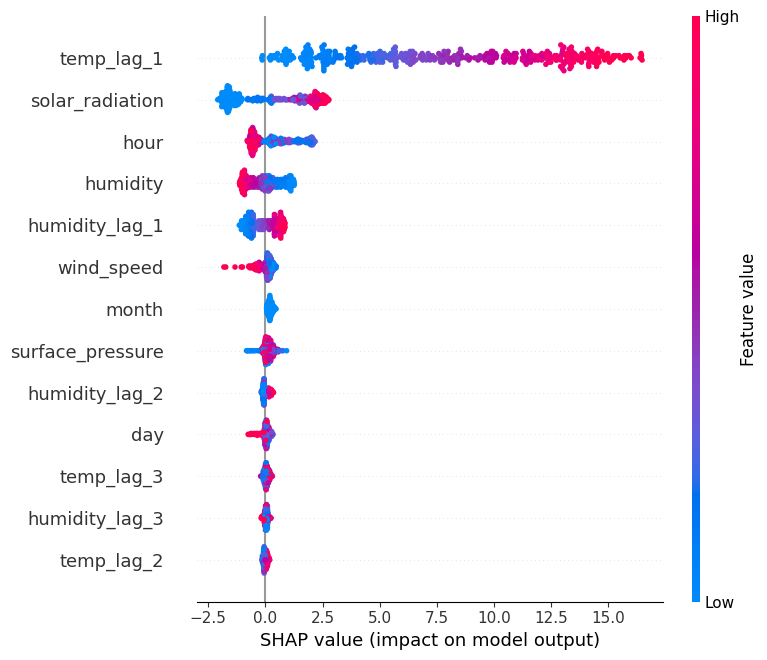

In [ ]:
# ============================================
# SHAP SUMMARY PLOT
# ============================================

plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    X_test
)

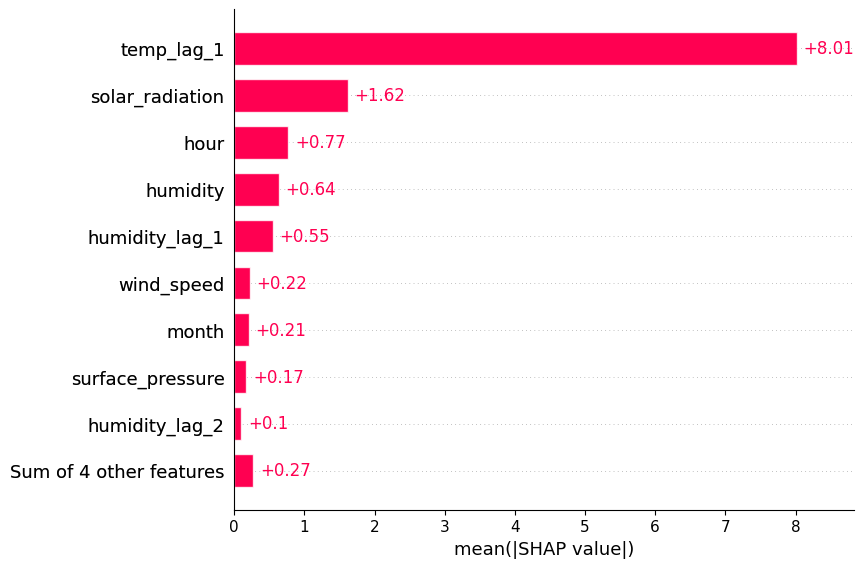

In [ ]:
# ============================================
# SHAP BAR IMPORTANCE PLOT
# ============================================

shap.plots.bar(shap_values)

In [ ]:
# ============================================
# INSTALL TENSORFLOW
# ============================================

!pip install tensorflow

In [ ]:
# ============================================
# IMPORT LSTM LIBRARIES
# ============================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.layers import Dropout

from sklearn.preprocessing import MinMaxScaler

print("TensorFlow imported successfully!")

TensorFlow imported successfully!


In [ ]:
# ============================================
# PREPARE DATA FOR LSTM
# ============================================

# Features for LSTM
lstm_features = [
    "temperature",
    "humidity",
    "solar_radiation",
    "surface_pressure",
    "wind_speed"
]

# Target
target = "temp_target_1h"

# ============================================
# SCALE DATA
# ============================================

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(df[lstm_features])

y_scaled = scaler_y.fit_transform(
    df[[target]]
)

# ============================================
# CREATE SEQUENCES
# ============================================

sequence_length = 24

X_lstm = []
y_lstm = []

for i in range(sequence_length, len(X_scaled)):

    X_lstm.append(
        X_scaled[i-sequence_length:i]
    )

    y_lstm.append(
        y_scaled[i]
    )

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)

print("LSTM Input Shape:", X_lstm.shape)
print("LSTM Target Shape:", y_lstm.shape)

LSTM Input Shape: (4314, 24, 5)
LSTM Target Shape: (4314, 1)


In [ ]:
# ============================================
# TRAIN TEST SPLIT FOR LSTM
# ============================================

split_index = int(len(X_lstm) * 0.9)

X_train_lstm = X_lstm[:split_index]
X_test_lstm = X_lstm[split_index:]

y_train_lstm = y_lstm[:split_index]
y_test_lstm = y_lstm[split_index:]

print("Training Shape:", X_train_lstm.shape)
print("Testing Shape :", X_test_lstm.shape)

Training Shape: (3882, 24, 5)
Testing Shape : (432, 24, 5)


In [ ]:
# ============================================
# BUILD LSTM MODEL
# ============================================

lstm_model = Sequential()

# LSTM Layer
lstm_model.add(
    LSTM(
        64,
        return_sequences=False,
        input_shape=(24, 5)
    )
)

# Dropout for regularization
lstm_model.add(Dropout(0.2))

# Output layer
lstm_model.add(Dense(1))

# ============================================
# COMPILE MODEL
# ============================================

lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

# Show model structure
lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,985 (70.25 KB)

 Trainable params: 17,985 (70.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================
# TRAIN LSTM MODEL
# ============================================

history = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=20,
    batch_size=32,
    validation_data=(X_test_lstm, y_test_lstm),
    verbose=1
)

Epoch 1/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0169 - val_loss: 0.0019
Epoch 2/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0044 - val_loss: 0.0011
Epoch 3/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0035 - val_loss: 0.0027
Epoch 4/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0030 - val_loss: 6.7604e-04
Epoch 5/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0027 - val_loss: 7.7703e-04
Epoch 6/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0025 - val_loss: 0.0015
Epoch 7/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0024 - val_loss: 6.1479e-04
Epoch 8/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0021 - val_loss: 7.8028e-04
Epoch 9/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0021 - val_loss: 0.0010
Epoch 10/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0019 - val_loss: 8.7967e-04
Epoch 11/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0019 - val_loss: 5.0717e-04
Epoch 12/20
122/1

In [ ]:
# ============================================
# MAKE PREDICTIONS
# ============================================

y_pred_lstm = lstm_model.predict(X_test_lstm)

# ============================================
# INVERSE SCALE PREDICTIONS
# ============================================

y_pred_lstm = scaler_y.inverse_transform(y_pred_lstm)

y_test_real = scaler_y.inverse_transform(y_test_lstm)

# ============================================
# EVALUATION METRICS
# ============================================

rmse_lstm = np.sqrt(
    mean_squared_error(
        y_test_real,
        y_pred_lstm
    )
)

r2_lstm = r2_score(
    y_test_real,
    y_pred_lstm
)

# ============================================
# DISPLAY RESULTS
# ============================================

print("LSTM Performance:")
print()

print(f"RMSE: {rmse_lstm:.4f}")
print(f"R² Score: {r2_lstm:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step
LSTM Performance:

RMSE: 0.7070
R² Score: 0.9844


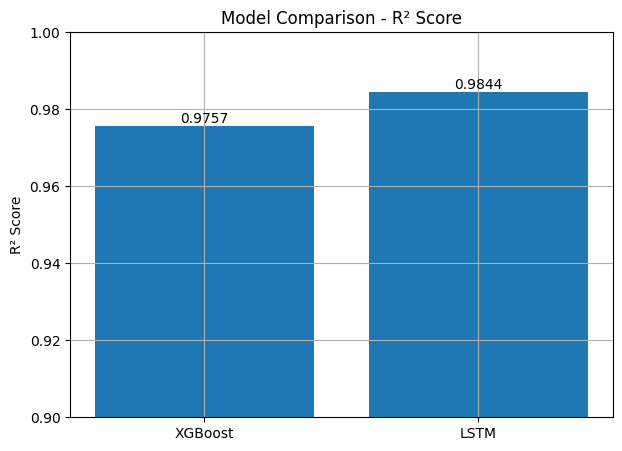

In [ ]:
# ============================================
# MODEL COMPARISON - R² SCORE
# ============================================

models = ["XGBoost", "LSTM"]

r2_scores = [
    0.9757,
    0.9844
]

plt.figure(figsize=(7,5))

bars = plt.bar(models, r2_scores)

plt.ylabel("R² Score")
plt.title("Model Comparison - R² Score")

plt.ylim(0.9, 1.0)

# Display values on bars
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.4f}",
        ha='center',
        va='bottom'
    )

plt.grid(True)

plt.show()

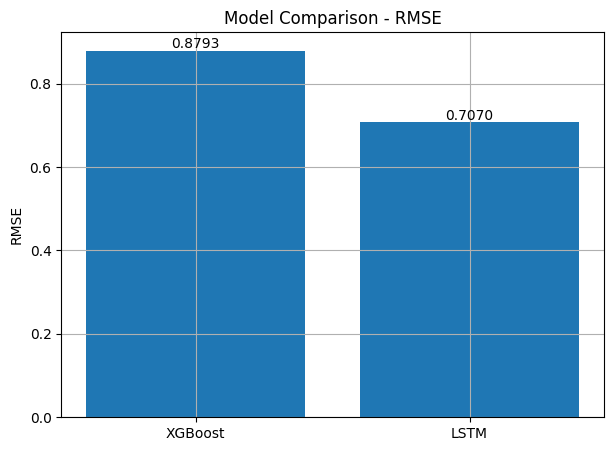

In [ ]:
# ============================================
# MODEL COMPARISON - RMSE
# ============================================

models = ["XGBoost", "LSTM"]

rmse_scores = [
    0.8793,
    0.7070
]

plt.figure(figsize=(7,5))

bars = plt.bar(models, rmse_scores)

plt.ylabel("RMSE")
plt.title("Model Comparison - RMSE")

# Display values
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.4f}",
        ha='center',
        va='bottom'
    )

plt.grid(True)

plt.show()

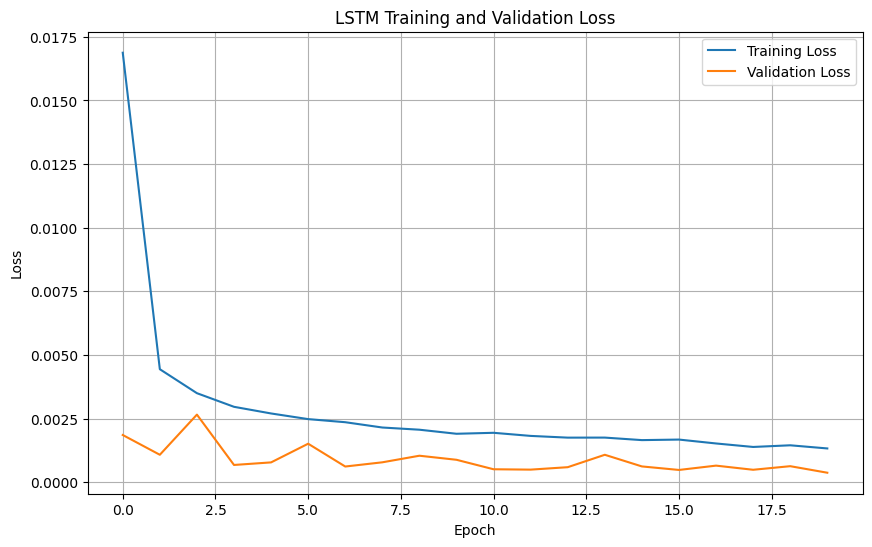

In [ ]:
# ============================================
# LSTM TRAINING CURVES
# ============================================

plt.figure(figsize=(10,6))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title("LSTM Training and Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

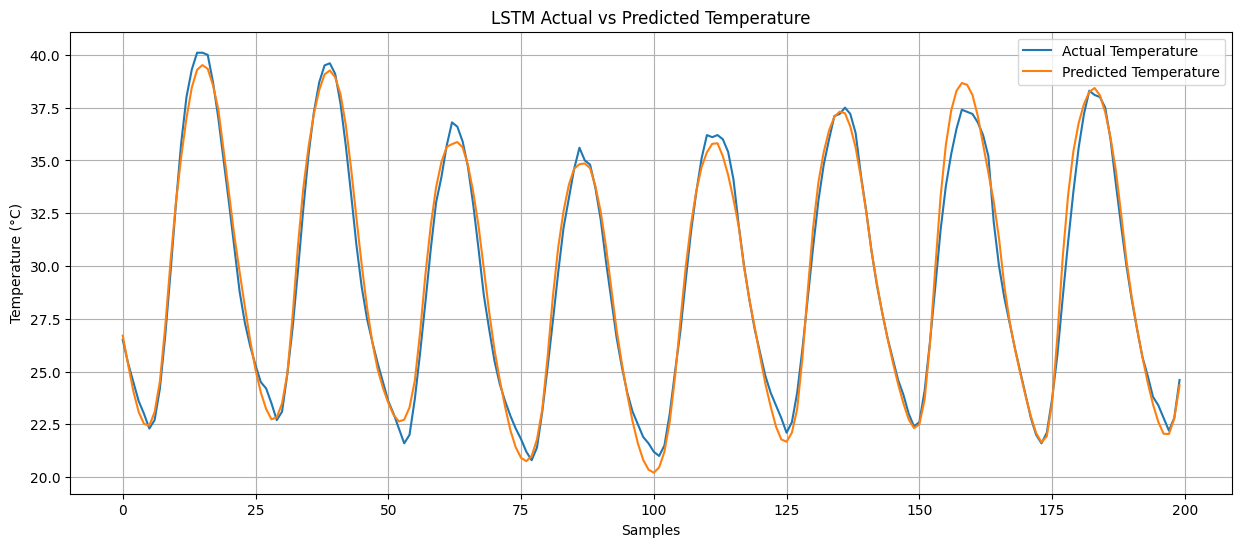

In [ ]:
# ============================================
# LSTM ACTUAL VS PREDICTED
# ============================================

plt.figure(figsize=(15,6))

plt.plot(
    y_test_real[:200],
    label="Actual Temperature"
)

plt.plot(
    y_pred_lstm[:200],
    label="Predicted Temperature"
)

plt.title("LSTM Actual vs Predicted Temperature")

plt.xlabel("Samples")
plt.ylabel("Temperature (°C)")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# ============================================
# FINAL MODEL COMPARISON TABLE
# ============================================

comparison_df = pd.DataFrame({
    "Model": ["XGBoost", "LSTM"],
    "RMSE": [0.8793, 0.7070],
    "R² Score": [0.9757, 0.9844]
})

print(comparison_df)

     Model    RMSE  R² Score
0  XGBoost  0.8793    0.9757
1     LSTM  0.7070    0.9844


In [ ]:
# ============================================================
# FULL COMPARATIVE ANALYSIS TABLE
# Replication + Comparative Study + Explainable AI
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CREATE FULL COMPARISON TABLE
# ============================================================

comparison_full_df = pd.DataFrame({

    "Aspect": [

        "Algorithm Type",
        "Learning Style",
        "Data Requirement",
        "Feature Engineering",
        "Sequential Learning",
        "Interpretability",
        "Explainable AI Support",
        "Training Speed",
        "Prediction Speed",
        "Computational Cost",
        "Memory Usage",
        "Handling Time-Series",
        "Captures Long-Term Dependencies",
        "Sensitivity to Scaling",
        "Hyperparameter Complexity",
        "Risk of Overfitting",
        "Model Complexity",
        "Ease of Implementation",
        "Best Forecasting Strength",
        "Weakness",
        "RMSE",
        "R² Score",
        "Overall Forecast Accuracy"

    ],

    "XGBoost": [

        "Gradient Boosting Ensemble",
        "Tree-Based Machine Learning",
        "Structured Tabular Data",
        "Manual Lag Features Required",
        "Limited",
        "High",
        "Excellent with SHAP",
        "Very Fast",
        "Very Fast",
        "Low",
        "Low",
        "Good",
        "Weak",
        "Not Sensitive",
        "Moderate",
        "Moderate",
        "Medium",
        "Easy",
        "Short-Term Structured Forecasting",
        "Limited Sequential Memory",
        "0.8793",
        "0.9757",
        "Excellent"

    ],

    "LSTM": [

        "Recurrent Neural Network",
        "Deep Learning",
        "Sequential Time-Series Data",
        "Automatic Feature Learning",
        "Excellent",
        "Low",
        "Limited",
        "Slow",
        "Moderate",
        "High",
        "Higher",
        "Excellent",
        "Strong",
        "Highly Sensitive",
        "High",
        "Higher",
        "High",
        "Moderate",
        "Temporal Sequence Learning",
        "Computationally Expensive",
        "0.7070",
        "0.9844",
        "Outstanding"

    ]

})

# ============================================================
# DISPLAY TABLE
# ============================================================

print("="*90)
print("FULL COMPARATIVE ANALYSIS")
print("="*90)

print(comparison_full_df)

# ============================================================
# OPTIONAL STYLING
# ============================================================

styled_table = comparison_full_df.style.set_properties(**{
    'text-align': 'center',
    'border': '1px solid black'
}).set_table_styles([
    {
        'selector': 'th',
        'props': [
            ('background-color', '#40466e'),
            ('color', 'white'),
            ('font-size', '12pt')
        ]
    }
])

styled_table

FULL COMPARATIVE ANALYSIS
                             Aspect                            XGBoost  \
0                    Algorithm Type         Gradient Boosting Ensemble   
1                    Learning Style        Tree-Based Machine Learning   
2                  Data Requirement            Structured Tabular Data   
3               Feature Engineering       Manual Lag Features Required   
4               Sequential Learning                            Limited   
5                  Interpretability                               High   
6            Explainable AI Support                Excellent with SHAP   
7                    Training Speed                          Very Fast   
8                  Prediction Speed                          Very Fast   
9                Computational Cost                                Low   
10                     Memory Usage                                Low   
11             Handling Time-Series                               Good   
12  Captures

,Aspect,XGBoost,LSTM
0,Algorithm Type,Gradient Boosting Ensemble,Recurrent Neural Network
1,Learning Style,Tree-Based Machine Learning,Deep Learning
2,Data Requirement,Structured Tabular Data,Sequential Time-Series Data
3,Feature Engineering,Manual Lag Features Required,Automatic Feature Learning
4,Sequential Learning,Limited,Excellent
5,Interpretability,High,Low
6,Explainable AI Support,Excellent with SHAP,Limited
7,Training Speed,Very Fast,Slow
8,Prediction Speed,Very Fast,Moderate
9,Computational Cost,Low,High


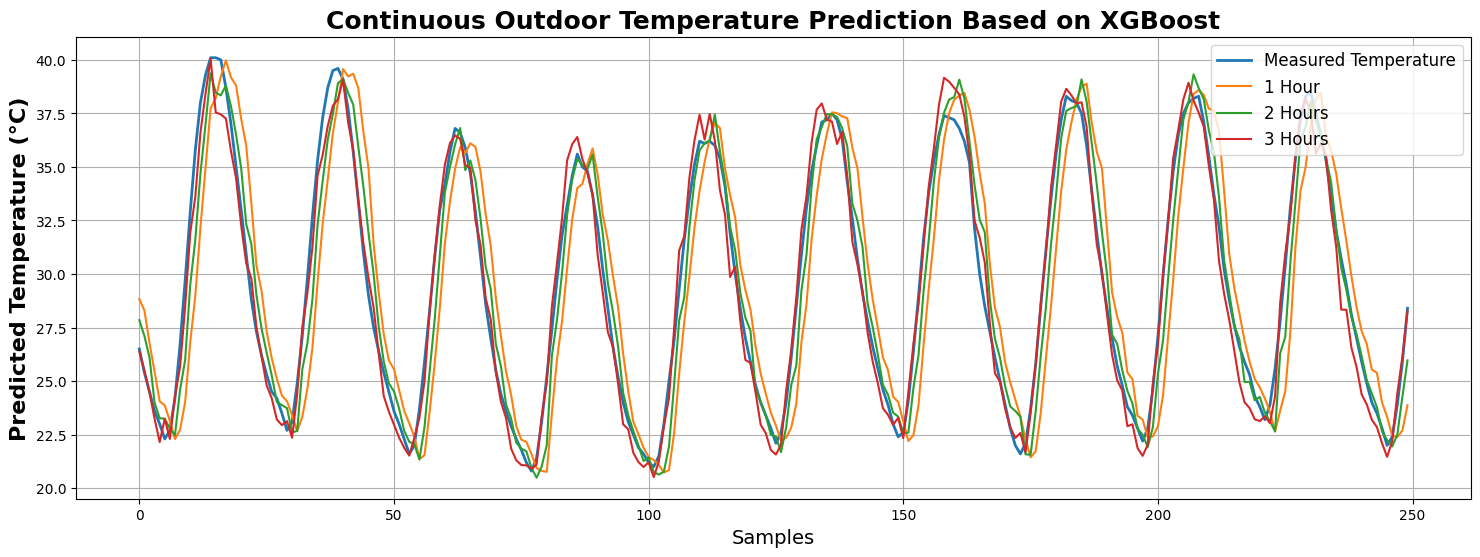

Combined prediction figure saved successfully!


In [ ]:
# ============================================================
# COMBINED XGBOOST MULTI-HORIZON PREDICTION PLOT
# Similar to Paper Figure 4
# ============================================================

# ============================================
# CREATE PREDICTIONS FOR ALL HORIZONS
# ============================================

targets = [
    "temp_target_1h",
    "temp_target_2h",
    "temp_target_3h"
]

predictions = {}

for target in targets:

    # Features
    X = df[features]

    # Target
    y = df[target]

    # Train/Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.1,
        shuffle=False
    )

    # Train XGBoost Model
    model = XGBRegressor(
        n_estimators=10000,
        learning_rate=0.05,
        max_depth=5,
        subsample=1,
        colsample_bytree=1,
        objective='reg:squarederror',
        random_state=42
    )

    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    predictions[target] = y_pred

# ============================================
# CREATE COMBINED FIGURE
# ============================================

plt.figure(figsize=(18,6))

# Actual temperature
plt.plot(
    y_test.values[:250],
    label='Measured Temperature',
    linewidth=2
)

# 1-hour prediction
plt.plot(
    predictions["temp_target_1h"][:250],
    label='1 Hour',
    linewidth=1.5
)

# 2-hour prediction
plt.plot(
    predictions["temp_target_2h"][:250],
    label='2 Hours',
    linewidth=1.5
)

# 3-hour prediction
plt.plot(
    predictions["temp_target_3h"][:250],
    label='3 Hours',
    linewidth=1.5
)

# ============================================
# STYLING
# ============================================

plt.title(
    "Continuous Outdoor Temperature Prediction Based on XGBoost",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel(
    "Samples",
    fontsize=14
)

plt.ylabel(
    "Predicted Temperature (°C)",
    fontsize=16,
    fontweight='bold'
)

plt.legend(
    fontsize=12
)

plt.grid(True)

# ============================================
# SAVE FIGURE
# ============================================

plt.savefig(
    "combined_xgboost_predictions.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Combined prediction figure saved successfully!")


Temperature Prediction Performance

  Predictive Horizon  R² Score    RMSE
0             1 Hour    0.9757  0.8793
1            2 Hours    0.9600  1.1291
2            3 Hours    0.9351  1.4381


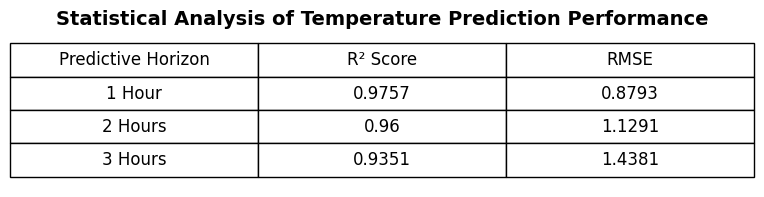

Performance table saved successfully!


In [ ]:
# ============================================================
# PERFORMANCE TABLE (LIKE PAPER TABLE 2)
# ============================================================

# Create comparison table

performance_df = pd.DataFrame({
    "Predictive Horizon": [
        "1 Hour",
        "2 Hours",
        "3 Hours"
    ],

    "R² Score": [
        0.9757,
        0.9600,
        0.9351
    ],

    "RMSE": [
        0.8793,
        1.1291,
        1.4381
    ]
})

# ============================================
# DISPLAY TABLE
# ============================================

print("\nTemperature Prediction Performance\n")
print(performance_df)

# ============================================
# OPTIONAL PROFESSIONAL VISUAL TABLE
# ============================================

fig, ax = plt.subplots(figsize=(8,2))

ax.axis('tight')
ax.axis('off')

table = ax.table(
    cellText=performance_df.values,
    colLabels=performance_df.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2)

plt.title(
    "Statistical Analysis of Temperature Prediction Performance",
    fontsize=14,
    fontweight='bold'
)

plt.savefig(
    "performance_table.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Performance table saved successfully!")

In [ ]:
# ============================================
# PREDICTIONS
# ============================================

y_pred = model.predict(X_test)

# ============================================
# METRICS
# ============================================

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# ============================================
# CREATE REGRESSION PLOT
# ============================================

plt.figure(figsize=(10,6))

# Scatter points
plt.scatter(
    y_test,
    y_pred,
    facecolors='none',
    edgecolors='blue',
    s=40
)

# Regression line
z = np.polyfit(y_test, y_pred, 1)
p = np.poly1d(z)

plt.plot(
    y_test,
    p(y_test),
    color='red',
    linewidth=2
)

# ============================================
# TEXT RESULTS
# ============================================

plt.text(
    min(y_test)+0.5,
    max(y_pred)-1,
    f"R-square = {r2:.2f}\nrmse = {rmse:.2f}",
    fontsize=16,
    fontweight='bold'
)

# ============================================
# TITLES & LABELS
# ============================================

plt.title(
    "3 Hours Predictive Horizon",
    fontsize=20,
    fontweight='bold'
)

plt.xlabel(
    "Measured Temperature (°C)",
    fontsize=16,
    fontweight='bold'
)

plt.ylabel(
    "Predicted Temperature (°C)",
    fontsize=16,
    fontweight='bold'
)

plt.grid(True)

# ============================================
# SAVE FIGURE
# ============================================

plt.savefig(
    "regression_3hour.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Regression figure saved successfully!")

NameError: name 'model' is not defined

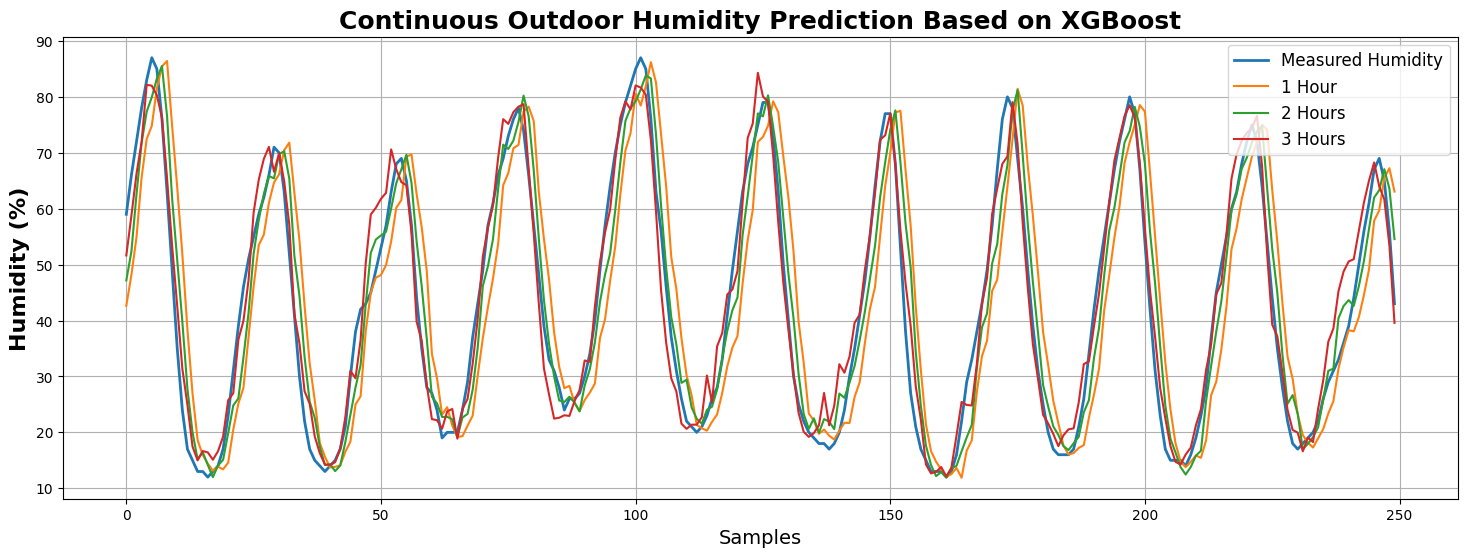

Humidity multi-horizon prediction plot saved!


In [ ]:
# ============================================================
# HUMIDITY PREDICTION - MULTI HORIZON CURVES
# XGBOOST ONLY
# Similar to Paper Figure 4
# ============================================================

humidity_targets = [
    "humidity_target_1h",
    "humidity_target_2h",
    "humidity_target_3h"
]

humidity_predictions = {}

for target in humidity_targets:

    # Features
    X = df[features]

    # Target
    y = df[target]

    # Train/Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.1,
        shuffle=False
    )

    # XGBoost Model
    model = XGBRegressor(
        n_estimators=10000,
        learning_rate=0.05,
        max_depth=5,
        subsample=1,
        colsample_bytree=1,
        objective='reg:squarederror',
        random_state=42
    )

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    humidity_predictions[target] = y_pred

# ============================================================
# COMBINED HUMIDITY CURVE
# ============================================================

plt.figure(figsize=(18,6))

# Actual humidity
plt.plot(
    y_test.values[:250],
    label='Measured Humidity',
    linewidth=2
)

# 1 hour
plt.plot(
    humidity_predictions["humidity_target_1h"][:250],
    label='1 Hour',
    linewidth=1.5
)

# 2 hours
plt.plot(
    humidity_predictions["humidity_target_2h"][:250],
    label='2 Hours',
    linewidth=1.5
)

# 3 hours
plt.plot(
    humidity_predictions["humidity_target_3h"][:250],
    label='3 Hours',
    linewidth=1.5
)

# ============================================================
# STYLING
# ============================================================

plt.title(
    "Continuous Outdoor Humidity Prediction Based on XGBoost",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel(
    "Samples",
    fontsize=14
)

plt.ylabel(
    "Humidity (%)",
    fontsize=16,
    fontweight='bold'
)

plt.legend(fontsize=12)

plt.grid(True)

# Save
plt.savefig(
    "combined_humidity_predictions.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Humidity multi-horizon prediction plot saved!")

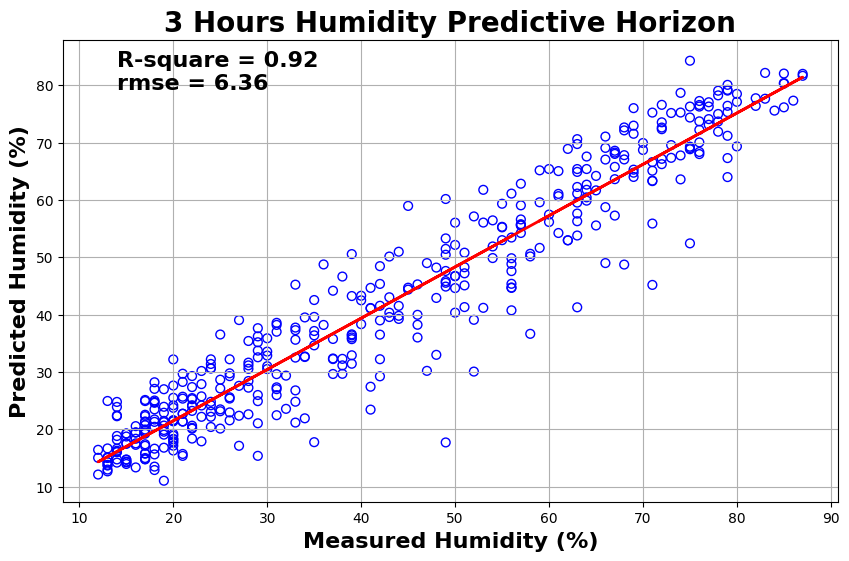


Humidity Prediction Performance (3 Hours)

RMSE : 6.3639
R² Score : 0.9168


In [ ]:

# ============================================================
# METRICS
# ============================================================

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# ============================================================
# REGRESSION PLOT
# ============================================================

plt.figure(figsize=(10,6))

# Scatter points
plt.scatter(
    y_test,
    y_pred,
    facecolors='none',
    edgecolors='blue',
    s=40
)

# Regression line
z = np.polyfit(y_test, y_pred, 1)
p = np.poly1d(z)

plt.plot(
    y_test,
    p(y_test),
    color='red',
    linewidth=2
)

# ============================================================
# TEXT RESULTS
# ============================================================

plt.text(
    min(y_test)+2,
    max(y_pred)-5,
    f"R-square = {r2:.2f}\nrmse = {rmse:.2f}",
    fontsize=16,
    fontweight='bold'
)

# ============================================================
# LABELS
# ============================================================

plt.title(
    "3 Hours Humidity Predictive Horizon",
    fontsize=20,
    fontweight='bold'
)

plt.xlabel(
    "Measured Humidity (%)",
    fontsize=16,
    fontweight='bold'
)

plt.ylabel(
    "Predicted Humidity (%)",
    fontsize=16,
    fontweight='bold'
)

plt.grid(True)

# Save
plt.savefig(
    "humidity_regression_3hour.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# ============================================================
# PRINT METRICS
# ============================================================

print("\nHumidity Prediction Performance (3 Hours)\n")

print(f"RMSE : {rmse:.4f}")
print(f"R² Score : {r2:.4f}")


Humidity Prediction Performance

  Predictive Horizon  R² Score    RMSE
0             1 Hour    0.9867  2.5459
1            2 Hours    0.9585  4.4930
2            3 Hours    0.9168  6.3639


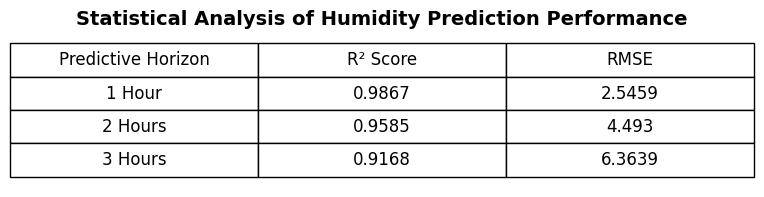

In [ ]:
# ============================================================
# HUMIDITY PERFORMANCE TABLE
# ============================================================

humidity_results = pd.DataFrame({

    "Predictive Horizon": [
        "1 Hour",
        "2 Hours",
        "3 Hours"
    ],

    "R² Score": [
        0.9867,
        0.9585,
        0.9168
    ],

    "RMSE": [
        2.5459,
        4.4930,
        6.3639
    ]
})

print("\nHumidity Prediction Performance\n")
print(humidity_results)

# ============================================================
# VISUAL TABLE
# ============================================================

fig, ax = plt.subplots(figsize=(8,2))

ax.axis('tight')
ax.axis('off')

table = ax.table(
    cellText=humidity_results.values,
    colLabels=humidity_results.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2)

plt.title(
    "Statistical Analysis of Humidity Prediction Performance",
    fontsize=14,
    fontweight='bold'
)

plt.savefig(
    "humidity_performance_table.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()